<a href="https://colab.research.google.com/github/vikasverma9721/Machine-Learning-Models/blob/main/INN_Hotel_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

## Context
#### A significant number of hotel bookings are called off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.
#### The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

##The cancellation of bookings impacts a hotel on various fronts:
1. Loss of resources (revenue) when the hotel cannot resell the room.
2. Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
3. Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
4. Human resources to make arrangements for the guests.


## Objective
#### The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

## Data Description
The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.
Data Dictionary
- Booking_ID: the unique identifier of each booking
- no_of_adults: Number of adults
- no_of_children: Number of Children
- no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
- no_of_week_nights: Number of weeknights (Monday to Friday) the guest stayed or booked to stay at the hotel
- type_of_meal_plan: Type of meal plan booked by the customer:
- Not Selected – No meal plan selected
- Meal Plan 1 – Breakfast
- Meal Plan 2 – Half board (breakfast and one other meal)
- Meal Plan 3 – Full board (breakfast, lunch, and dinner)
- required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
- room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels Group
- lead_time: Number of days between the date of booking and the arrival date
- arrival_year: Year of arrival date
- arrival_month: Month of arrival date
- arrival_date: Date of the month
- market_segment_type: Market segment designation.
- repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
- no_of_previous_cancellations: Number of previous bookings that were canceled by the customer before the current booking
no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer before the current booking
- avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
- no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
- booking_status: Flag indicating if the booking was canceled or not.


### Import Necessary Libraries

In [ ]:
# Libraries to help raeding and manpulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# Library to feature scaling
from sklearn.preprocessing import StandardScaler

# To get deferent metrix scores
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

# To Biuld model for prediction
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# To ignore unnessary warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/INNHotelsGroup.csv")

### Data Overview

In [ ]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
df.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled


### Check Shape

In [ ]:
df.shape

(36275, 19)

### Check the data types of the columns for the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

### Check Null values

In [ ]:
df.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


### Check Duplicate values

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
36270,False
36271,False
36272,False
36273,False


### Statistical summary

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


### Drop Unnecssary column

In [ ]:
df1 = df.drop(["Booking_ID"], axis = 1)

- Drop Kooking_ID because we don't need it.

In [ ]:
df1.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


### Exploratory Data Analysis (EDA)

### 1. What are the busiest months in the hotel?

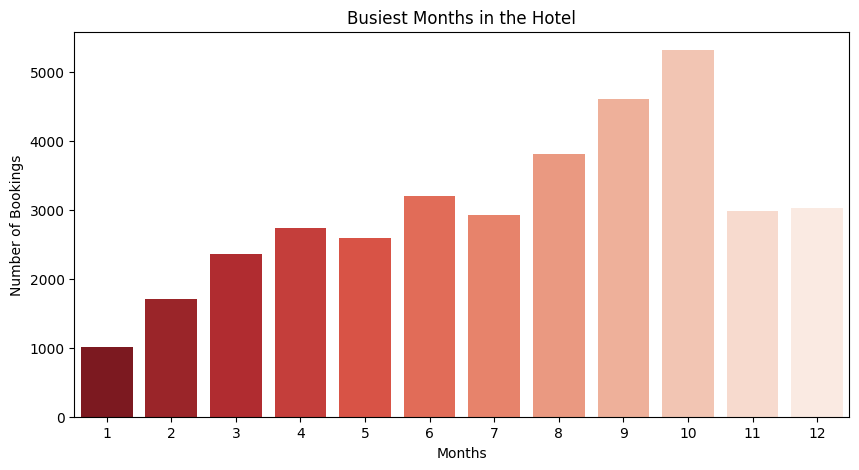

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(data = df1, x = "arrival_month", palette = "Reds_r")
plt.title("Busiest Months in the Hotel")
plt.xlabel("Months")
plt.ylabel("Number of Bookings")
plt.show()

- Peak Months: The hotel is busiest in October (Month 10) and September (Month 9), showing maximum booking volume.

- Lowest Period: January (Month 1) experiences the lowest demand with minimal reservations.

- Trend: Bookings show a steady upward seasonal trend from the beginning of the year toward the end of the third quarter.

### 2. Which market segment do most of the guests come from?

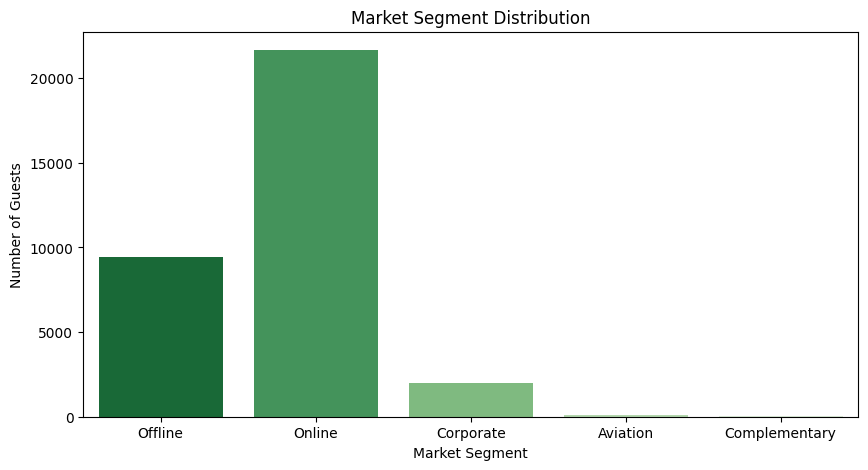

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(data = df1, x = "market_segment_type", palette = "Greens_r")
plt.title("Market Segment Distribution")
plt.xlabel("Market Segment")
plt.ylabel("Number of Guests")
plt.show()

- Dominant Segment: The vast majority of hotel guests book through the Online market segment, making it the primary revenue driver (exceeding $20,000$ bookings).
- Secondary Channel: The Offline segment is the second largest channel, represents a moderate share of bookings (around $9,500$).
- Minor Segments: B2B channels like Corporate, Aviation, and Complementary show minimal contributions to the overall booking distribution.

### 3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?

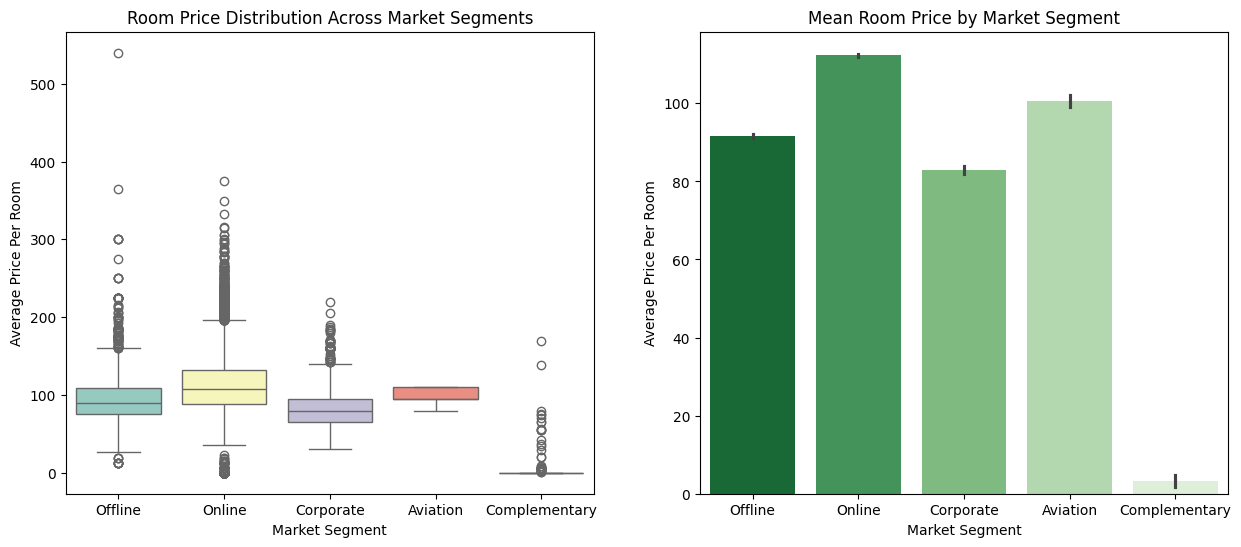

In [ ]:
plt.figure(figsize = (15,6))
plt.subplot(1,2,1)
sns.boxplot(data = df1, x = "market_segment_type", y = "avg_price_per_room", palette = "Set3")
plt.title("Room Price Distribution Across Market Segments")
plt.xlabel("Market Segment")
plt.ylabel("Average Price Per Room")


plt.subplot(1,2,2)
sns.barplot(data = df1, x = "market_segment_type", y = "avg_price_per_room", palette = "Greens_r")
plt.title("Mean Room Price by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Average Price Per Room")
plt.show()

- Highest Room Rates: The Online market segment generates the highest average room prices, with the mean price crossing $100$ units and showing a wide distribution with several high-value outliers.
- Aviation Premium: The Aviation segment also maintains a high and stable premium price point, tracking closely behind the online segment.- -
- Lowest/Free Rates: The Complementary segment expectedly shows a mean price near or at $0$, as these represent free stays or promotional bookings.
- Corporate & Offline stability: Corporate and Offline segments offer moderate, stable pricing with tighter distributions, indicating structured or contract-based rates.

### 4. What percentage of bookings are canceled?

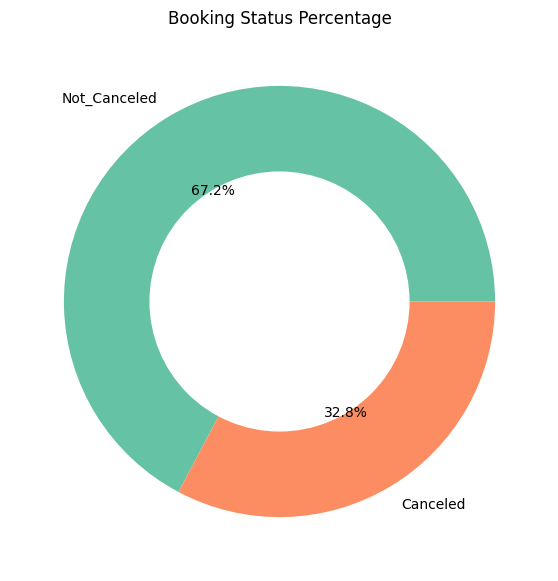

In [ ]:
counts = df['booking_status'].value_counts()

colors = sns.color_palette("Set2", n_colors=len(counts))


plt.figure(figsize=(7, 7))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors = colors)

white_circle = plt.Circle((0,0), 0.6, color='white')

plt.gca().add_artist(white_circle)

plt.title('Booking Status Percentage')
plt.show()

- Majority Retained: The largest portion of hotel reservations remains intact, with 67.2% of total bookings successfully checking in as Not_Canceled.

- Significant Cancellation Rate: A substantial 32.8% of all generated hotel bookings end up being Canceled, presenting a major operational risk.

- Class Imbalance: The chart highlights a noticeable class imbalance (roughly a 2:1 ratio), which heavily justifies why specific machine learning techniques and evaluation metrics like Confusion Matrix were required during modeling.

### 5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?

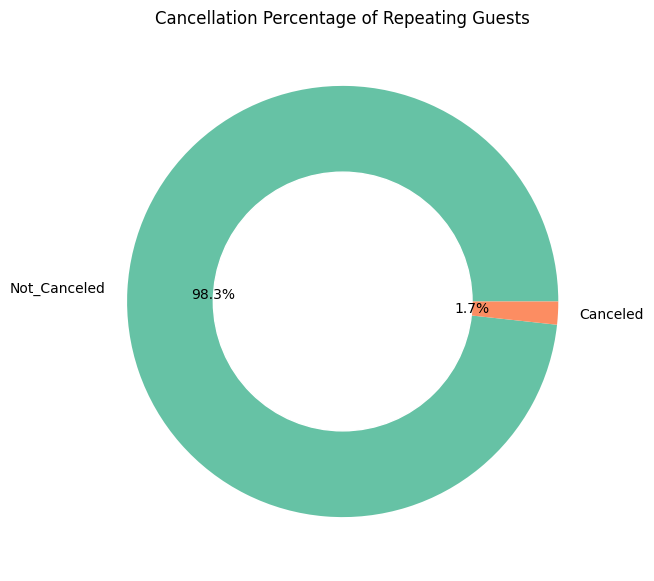

In [ ]:
repeating_guests = df1[df1['repeated_guest'] == 1]
counts = repeating_guests['booking_status'].value_counts()

colors = sns.color_palette("Set2", n_colors=len(counts))


plt.figure(figsize = (7,7))
plt.pie(counts, labels = counts.index, autopct = '%1.1f%%', colors = colors)
white_circle = plt.Circle((0,0), 0.6, color = 'white')
plt.gca().add_artist(white_circle)
plt.title("Cancellation Percentage of Repeating Guests")
plt.show()

- High Loyalty & Retention: Repeating guests exhibit exceptional loyalty, with an overwhelming 98.3% of their bookings remaining Not_Canceled.

- Negligible Cancellations: The cancellation rate among returning guests is minimal, standing at just 1.7%.

- Key Insight: This stark contrast suggests that "Repeat Guest" status is a highly reliable feature for the machine learning model to predict a low probability of cancellation.

### 6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?

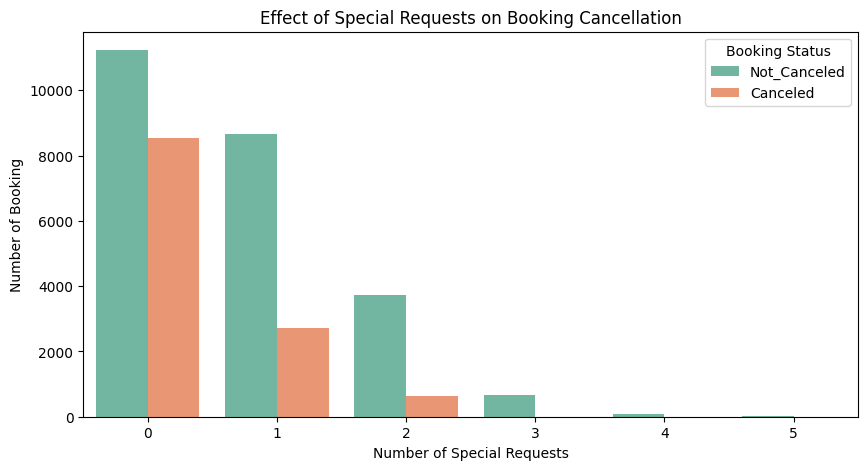

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(data = df1, x = "no_of_special_requests", hue = "booking_status", palette = "Set2")
plt.title("Effect of Special Requests on Booking Cancellation")
plt.xlabel("Number of Special Requests")
plt.ylabel("Number of Booking")
plt.legend(title = "Booking Status")
plt.show()


- Inverse Relationship: Booking cancellations drop significantly as the number of special requests increases from 0 to 5.
- Highest Risk Group: Guests with 0 special requests have the highest cancellation volume (exceeding $8,000$ bookings), making them a high-risk segment.
- High Engagement Retention: Customers who make 1 or more special requests are much more likely to complete their stay (Not_Canceled), indicating higher booking intent and customer engagement.

### Univariate Analysis

In [ ]:
# numerical variable
def histplot_boxplot_analysis(df1, feature):
  if df1[feature].dtype in ['int64', 'float64']:
    # histplot and boxplot setup
    fig, axes = plt.subplots(1,2, figsize = (14,5))
    sns.histplot(data = df1, x = feature, kde = True, ax = axes[0], color = 'red')
    axes[0].set_title(f"Distribution of {feature}")

    sns.boxplot(data = df1, x = feature, ax = axes[1], color = 'red')
    axes[1].set_title(f"Box of {feature}")
    plt.tight_layout()
    plt.show()
  else:
    print(f"Feature '{feature}' is not a numeric type (int64 or float64).")


# categorical variable
def labeled_barplot_analysis(df1, feature):

  plt.figure(figsize = (10,5))
  ax = sns.countplot(data = df1, x = feature, palette = "Set2")

  total = len(df1[feature])
  for x in ax.patches:
    percentage = f"{100 * x.get_height() / total:.1f}%"
    x_pos = x.get_x() + x.get_width() / 2
    y_pos = x.get_height()
    ax.annotate(percentage, (x_pos, y_pos), ha = "center", va = "bottom", fontsize = 10, fontweight = "bold")
  plt.show()

### Observations on no_of_adults

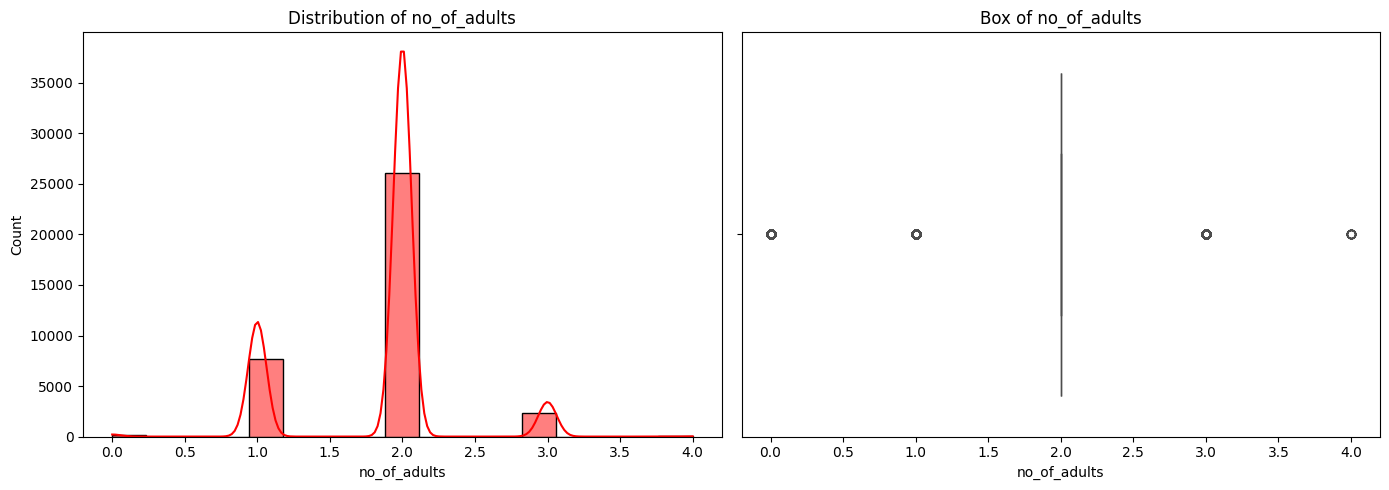

In [ ]:
histplot_boxplot_analysis(df1, "no_of_adults")

- Dominant Category: The vast majority of bookings are for exactly 2 adults, as indicated by the highest peak in the histplot and the median in the boxplot.

- Secondary Group: A significant but much smaller number of bookings consist of 1 adult only.

- Outliers Detected: Very few bookings involve 3 or 4 adults, which are considered statistical outliers in this numerical feature distribution.

### Observations on no_of_children

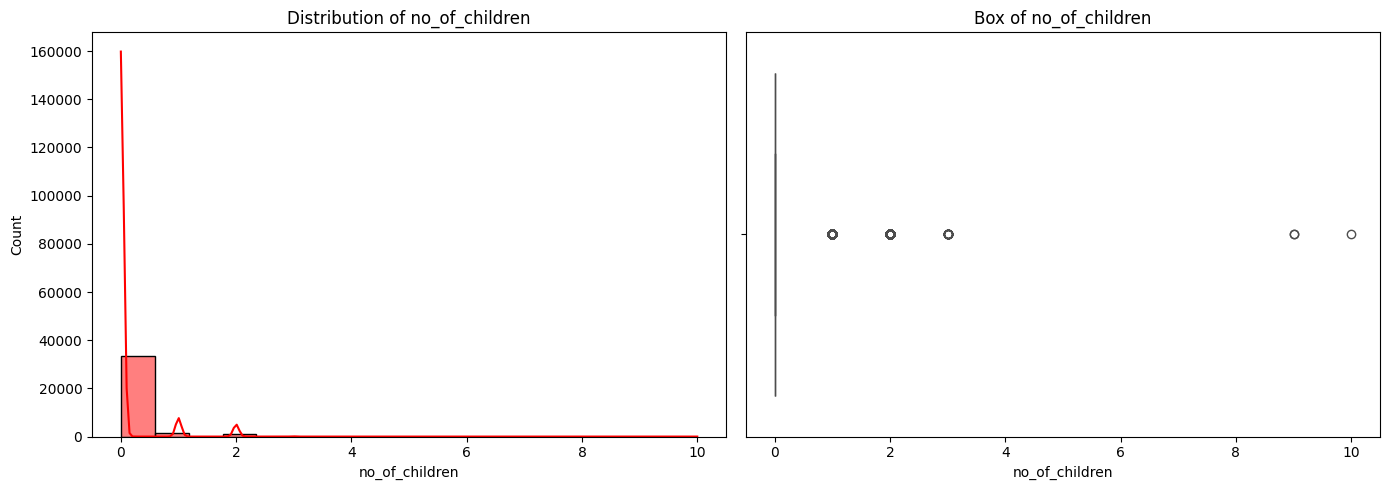

In [ ]:
histplot_boxplot_analysis(df1, "no_of_children")

- Extreme Majority with Zero Children: The histogram and boxplot confirm an extreme class imbalance, with the vast majority of all bookings involving zero (0) children.

- Highly Skewed Distribution: The 'Distribution of no_of_children' histogram shows a near-vertical peak at 0 and is extremely right-skewed, indicating very few families book with multiple children.

- Outliers Detected: Bookings with 1 or more children appear as infrequent data points or outliers, highlighting their low occurrence in the dataset.

- Minimal Variance: There is almost no variance in the feature, as the median and almost all data cluster tightly around zero.

-

### Observations on no_of_weekend_nights

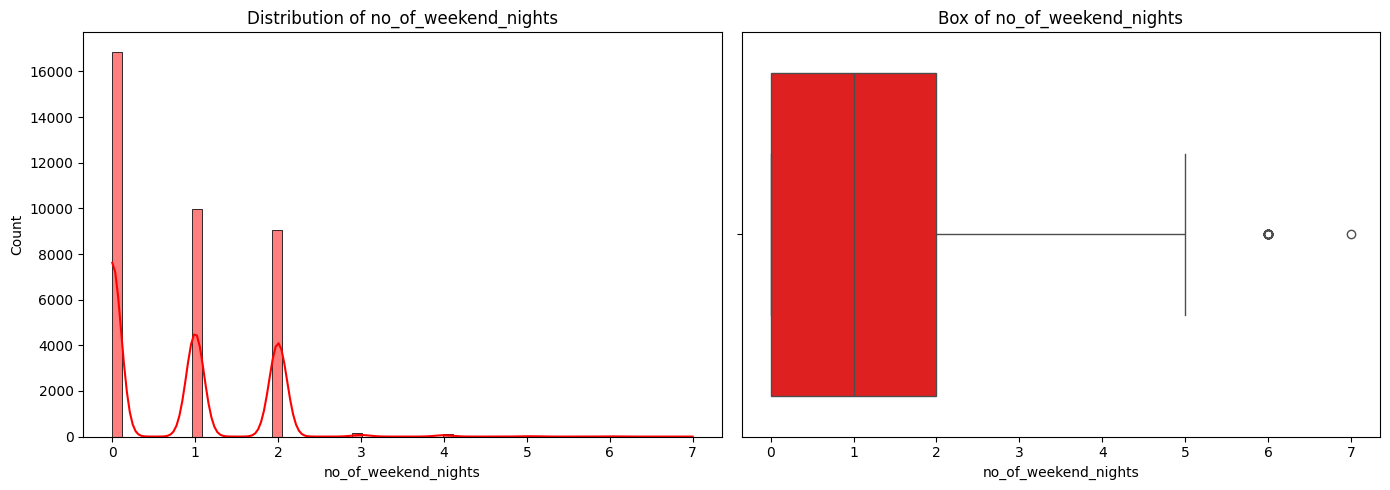

In [ ]:
histplot_boxplot_analysis(df1, "no_of_weekend_nights")

- Dominant Pattern: The majority of guests prefer stays with 0 weekend nights, making weekday-only bookings the most common category.

- Standard Weekend Stays: Stays with 1 or 2 weekend nights are also quite frequent, representing standard short-term weekend trips.

- Distribution Skew: The feature is heavily right-skewed, meaning that extended stays involving 3 or more weekend nights are extremely rare.

### Observations on no_of_week_nights

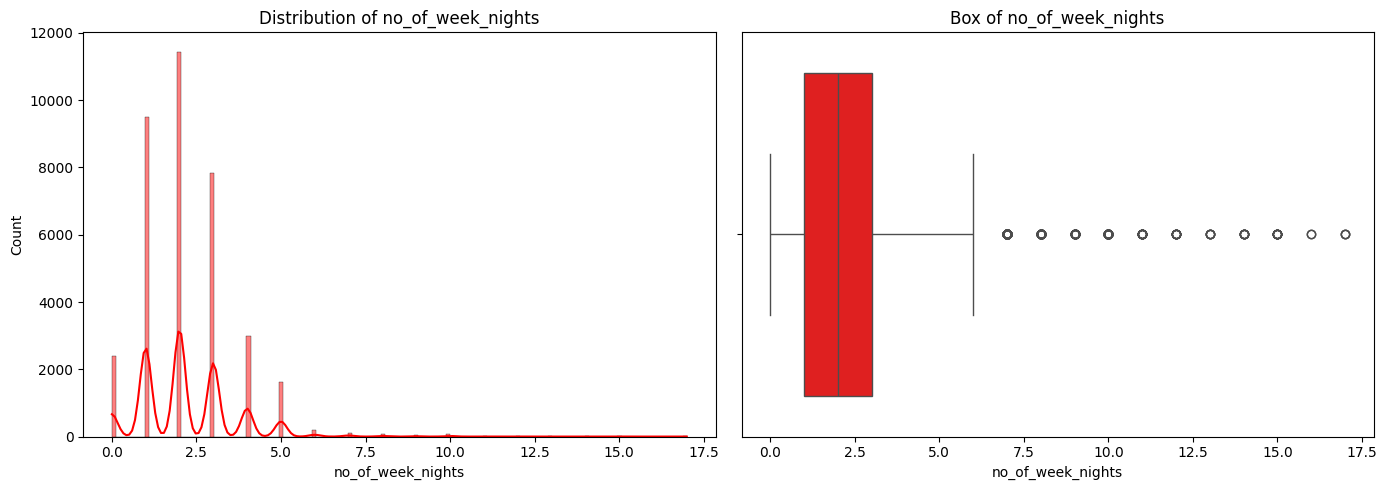

In [ ]:
histplot_boxplot_analysis(df1, "no_of_week_nights")

- Peak Duration: Most guests stay for shorter durations, with 2 week nights being the most frequent choice, closely followed by 1 and 3 nights.

- Central Tendency: The median number of week nights per booking lies around 2 to 3 nights, as clearly shown by the red boxplot.

- Outliers Identified: The distribution is right-skewed with significant outliers extending beyond 6 nights, including rare long-term bookings up to 10 or 17 week nights.

### Observations on required_car_parking_space

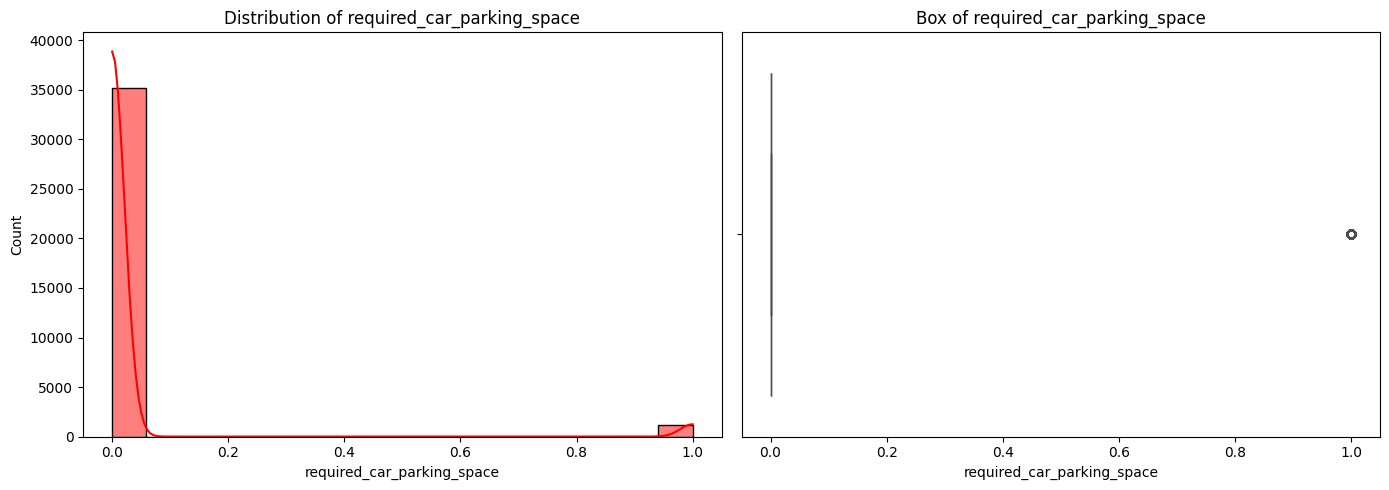

In [ ]:
histplot_boxplot_analysis(df1, "required_car_parking_space")

- Minimal Parking Demand: An overwhelming majority of guests (nearly 35,000+ bookings) do not require any car parking space (0) during their stay.

- Extremely Rare Requests: A very tiny fraction of bookings request exactly 1 parking space, making it an infrequent event in the dataset.

- High Imbalance & Skew: The feature is extremely right-skewed with close to zero variance, indicating that parking availability is rarely a critical factor for the majority of hotel reservations.

### Observations on lead_time

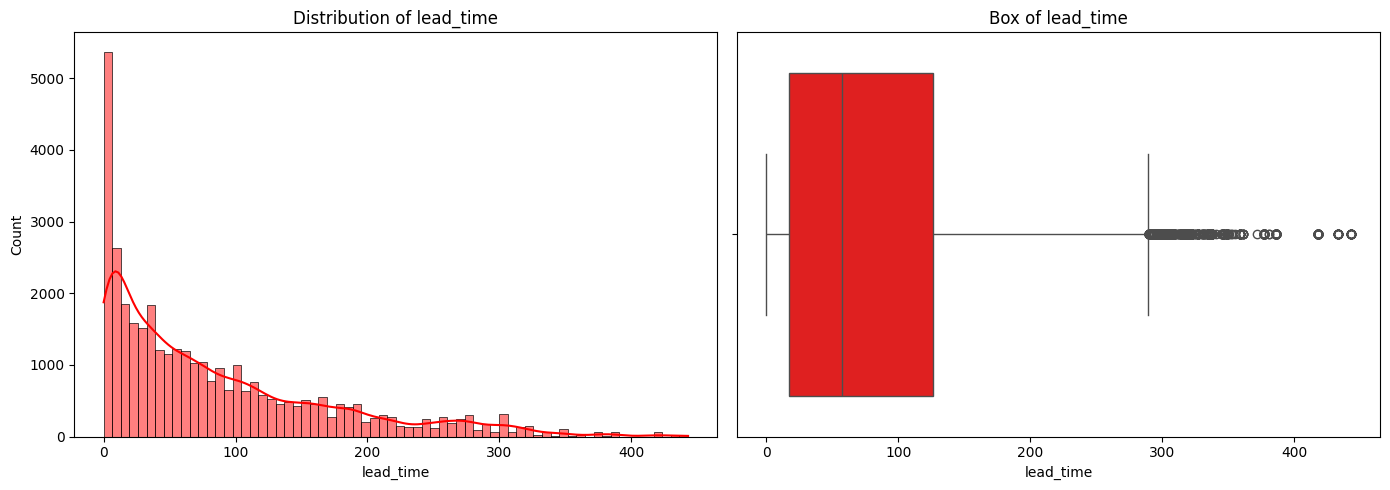

In [ ]:
histplot_boxplot_analysis(df1, "lead_time")

- Right-Skewed Distribution: The majority of reservations are made with very low lead time, peaking sharply close to 0 to 50 days before arrival.

- Moderate to High Spread: The red boxplot shows a wide interquartile range (IQR), indicating that a significant portion of guests also book between 50 and 130 days in advance.

- Extreme Outliers: There is a long tail extending up to 400+ days, with several extreme outliers visible beyond the 300-day mark on the boxplot.

### Observations on arrival_year

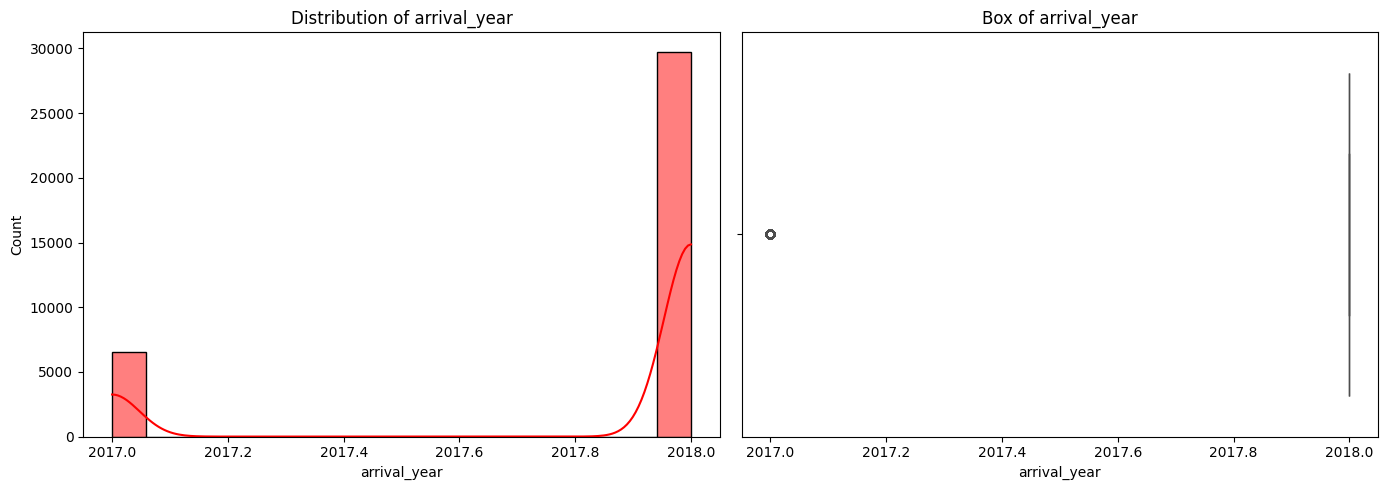

In [ ]:
histplot_boxplot_analysis(df1, "arrival_year")

- Dominant Year: The vast majority of hotel bookings are concentrated in the year 2018, showing a massive spike compared to the previous year.

- Secondary Period: The year 2017 records a significantly lower volume of bookings (less than 10,000).

- Data Nature: This feature behaves like a categorical or binary distribution because it only contains discrete data for two specific years (2017 and 2018), which causes the boxplot to display 2017 as an outlier point.

### Observations on arrival_month

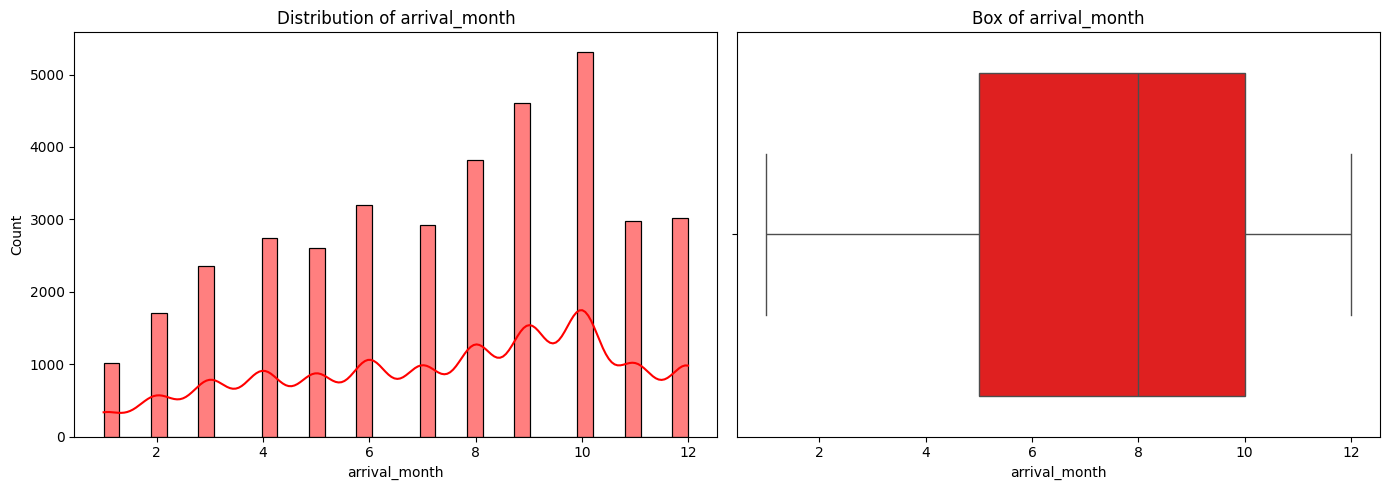

In [ ]:
histplot_boxplot_analysis(df1, "arrival_month")

- Peak Season: Hotel bookings clearly peak in October (Month 10), closely followed by September (Month 9), showing the highest customer influx.

- Trough Period: The lowest reservation volume occurs in January (Month 1), marking the absolute slack season for the hotel.

- Quarterly Trend: Bookings display a steady upward trajectory from the first quarter through the end of the third quarter, while the boxplot indicates a median centered around August (Month 8).

### Observations on arrival_date

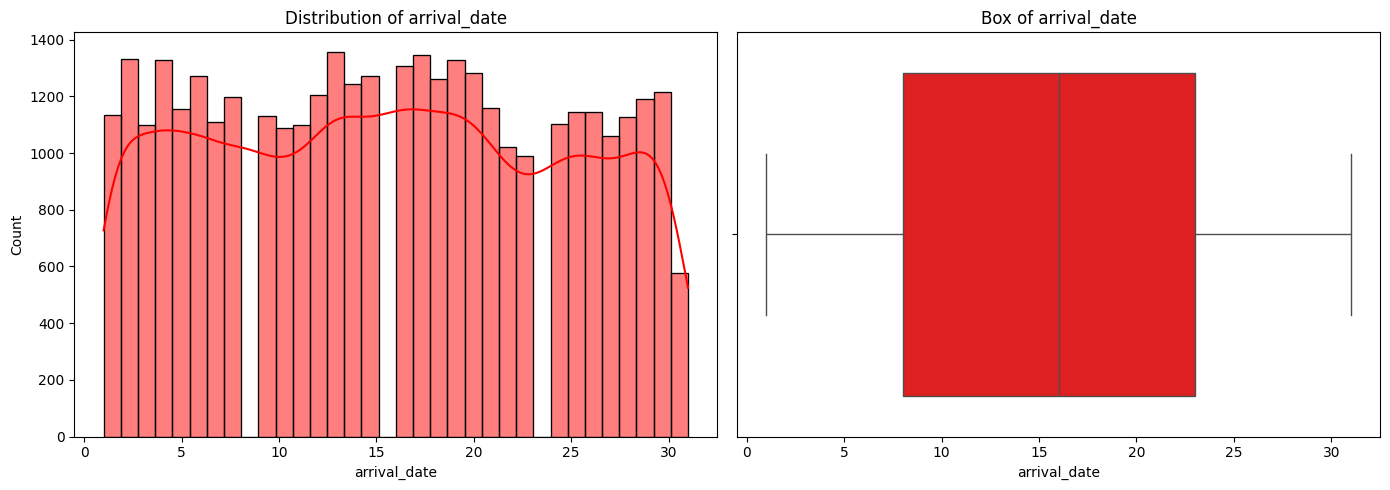

In [ ]:
histplot_boxplot_analysis(df1, "arrival_date")

- Uniform Distribution: Bookings are fairly evenly distributed across almost all days of the month (from 1st to 30th), showing no massive single-day spikes.

- Month-End Drop: There is a noticeable dip on the 31st day, which is statistically expected since not all months have 31 days.

- Symmetrical Spread: The red boxplot shows a perfectly centered median around the 16th day with a well-balanced Interquartile Range (IQR) and no statistical outliers.

### Observations on repeated_guest

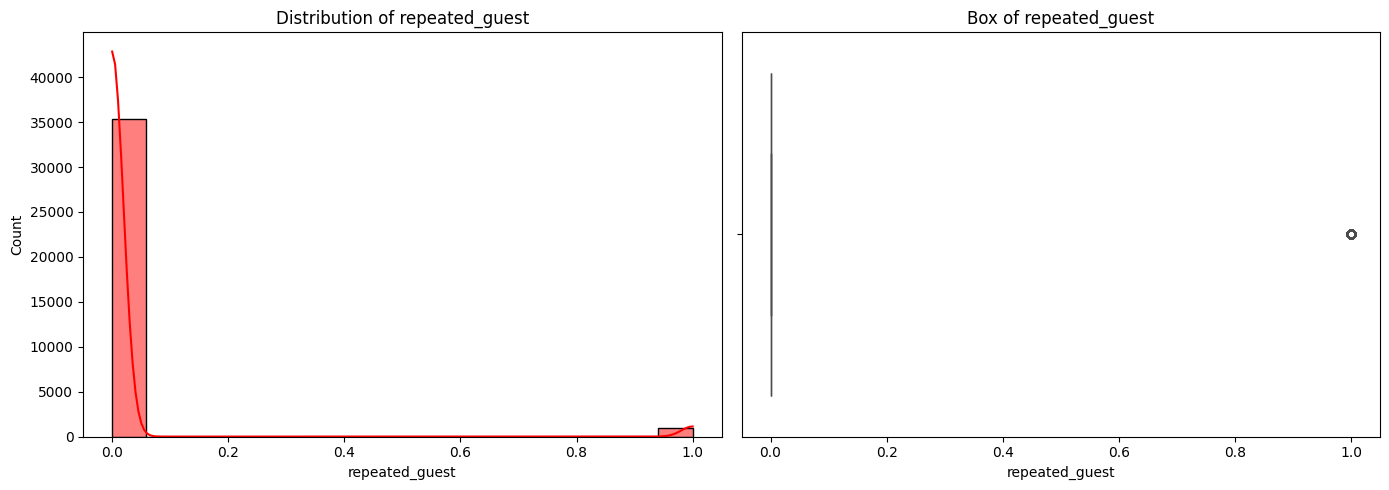

In [ ]:
histplot_boxplot_analysis(df1, "repeated_guest")

- Extreme Class Imbalance: The overwhelming majority of hotel bookings are from new guests (0), causing a huge peak at zero.
- Low Retention Volume: A very small, minor fraction of reservations come from repeated guests (1) who have stayed at the hotel before.
- Binary Distribution: This feature is strictly binary/categorical ($0$ or $1$), making the data highly skewed with a near-zero variance for the majority class.

### Observations on no_of_previous_cancellations

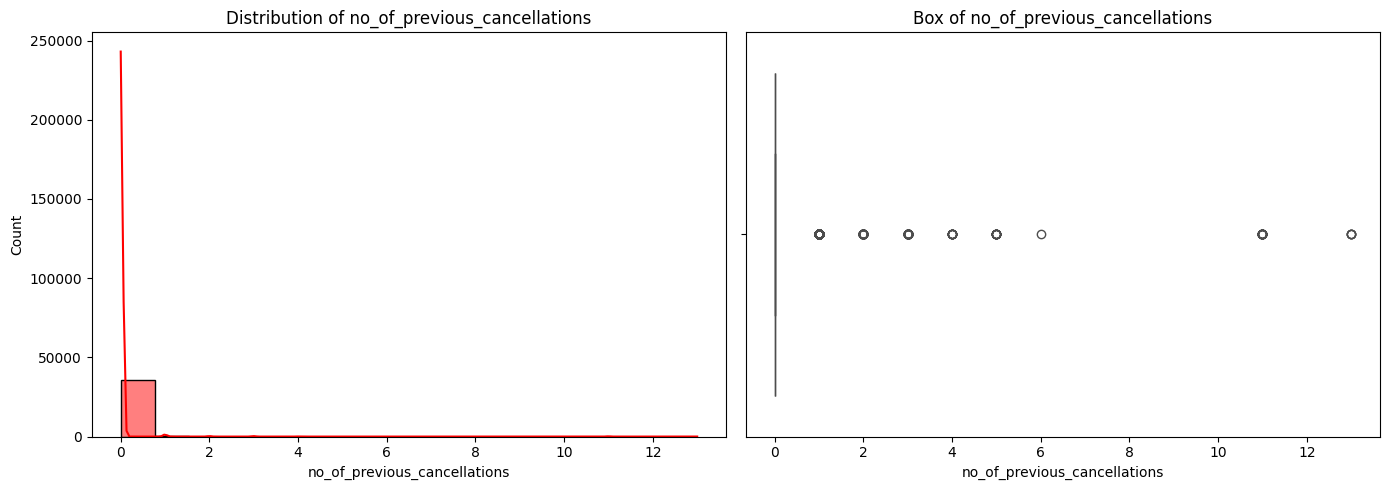

In [ ]:
histplot_boxplot_analysis(df1, "no_of_previous_cancellations")

- Zero Cancellation Dominance: The extreme peak at 0 shows that the vast majority of customers have never canceled a booking prior to this reservation.

- Heavy Right Skew: The distribution is heavily right-skewed with near-zero variance for the main data chunk, as most rows cluster tightly at zero.

- Presence of Outliers: There are a few scattered outliers visible on the long tail and boxplot, representing rare cases where a customer has multiple past cancellations.

### Observations on no_of_previous_bookings_not_canceled

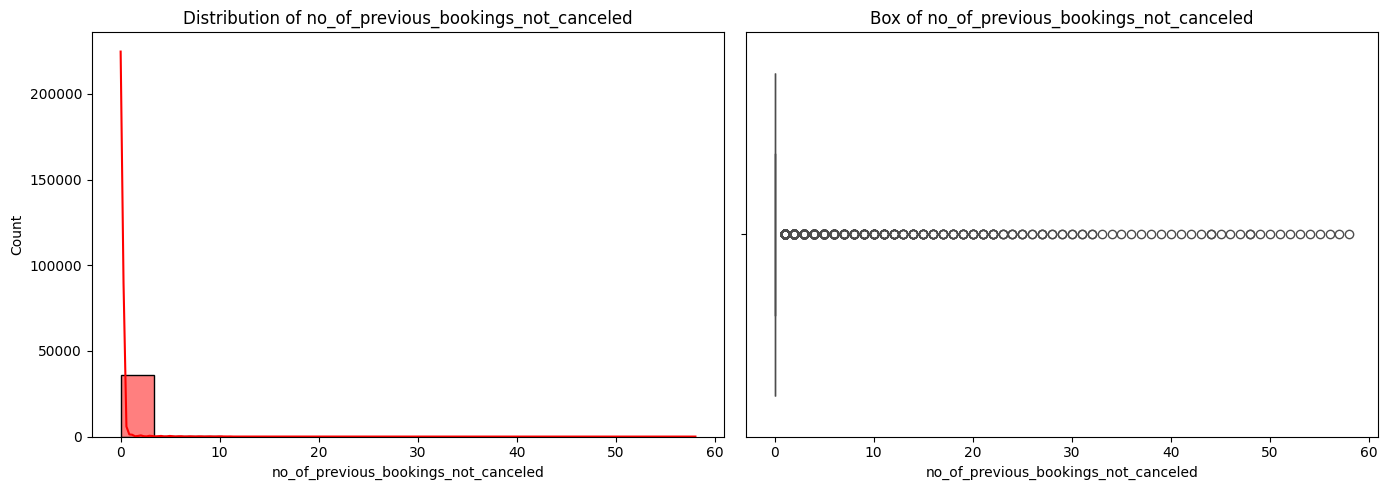

In [ ]:
histplot_boxplot_analysis(df1, "no_of_previous_bookings_not_canceled")

- Massive Peak at Zero: The vast majority of observations stand at 0, showing that most entries are new customers without any prior successful stays.

- Extreme Right Skew: The distribution is heavily right-skewed, meaning that variance is concentrated almost entirely at the starting point.

- Extensive Outlier Chain: The boxplot displays a long, continuous sequence of outliers stretching up to 60, representing rare and highly loyal repeat customers.

### Observations on avg_price_per_room

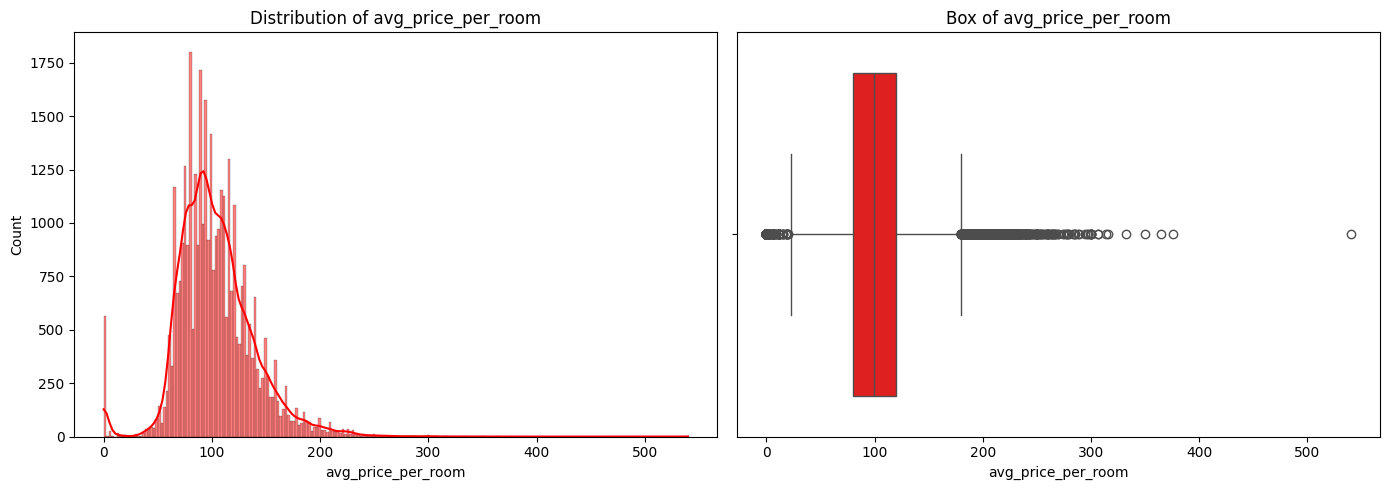

In [ ]:
histplot_boxplot_analysis(df1, "avg_price_per_room")

- Normal-Like Distribution: The room prices follow a slightly right-skewed, near-normal distribution, with most bookings peaking tightly around 80 to 110 units.

- Zero-Price Peak: There is a distinct small spike exactly at 0, which represents promotional offers, complimentary stays, or free vouchers.

- Heavy Outliers: The red boxplot reveals a high density of outliers on both ends—especially a long tail stretching up to 300+ units on the higher side.

### Observations on no_of_special_requests

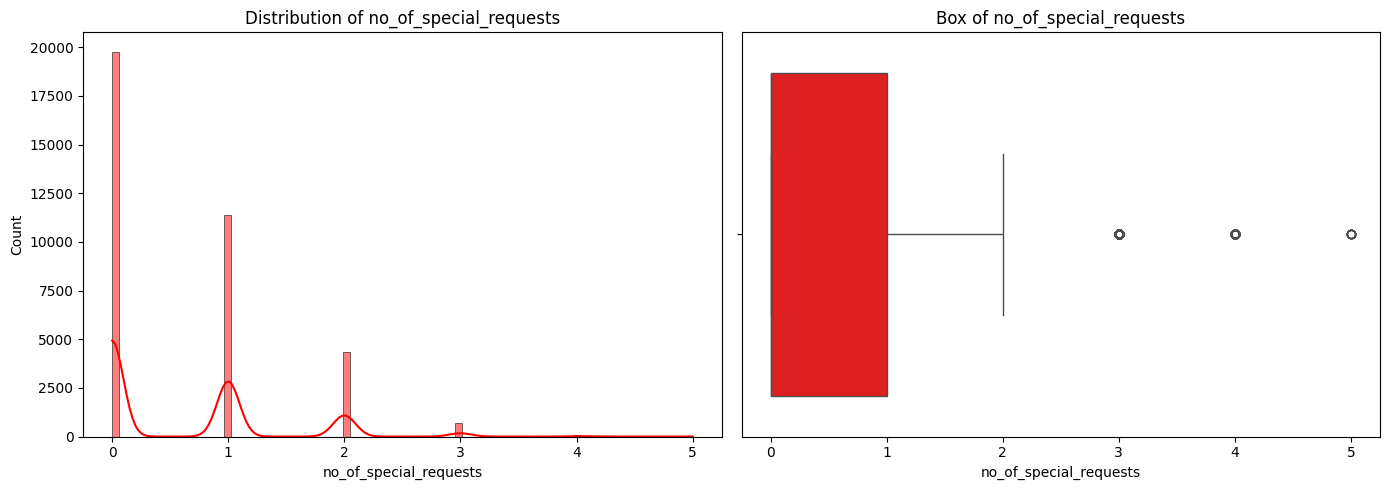

In [ ]:
histplot_boxplot_analysis(df1, "no_of_special_requests")

- Zero Requests Dominance: The majority of bookings (around 20,000) have 0 special requests, making it the most frequent category.

- Step-Down Pattern: There is a clear decreasing trend, with the count of bookings dropping sharply as the number of requests moves from 1 to 2, and then down to 3.

- Statistical Outliers: The red boxplot indicates that higher counts of requests, specifically 3, 4, or 5 requests, are rare enough to be flagged as outliers.

### Observations on market_segment_type

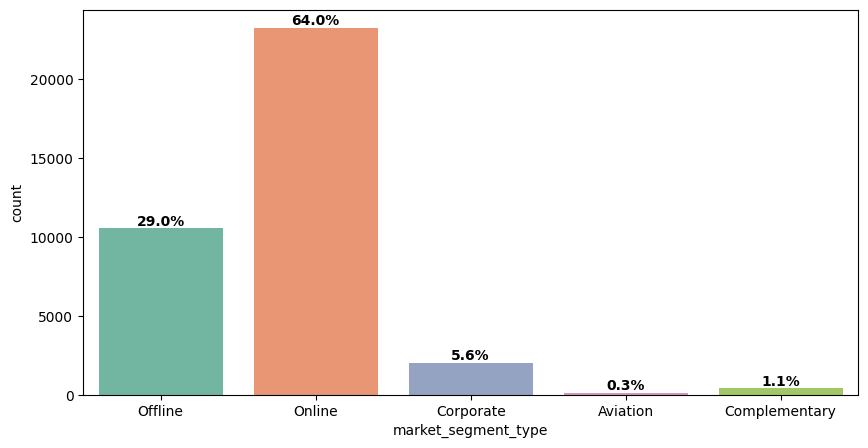

In [ ]:
labeled_barplot_analysis(df1, "market_segment_type")

- Dominant Channel: The Online segment is the primary source of revenue, accounting for the absolute majority with 64.0% of all hotel bookings.

- Secondary Channel: The Offline segment represents the second largest category, capturing 29.0% of the total reservations.

- Minority Segments: Corporate (5.6%), Complementary (1.1%), and Aviation (0.3%) segments contribute minimally, making up less than 8% of the dataset combined.

### Observations on booking_status

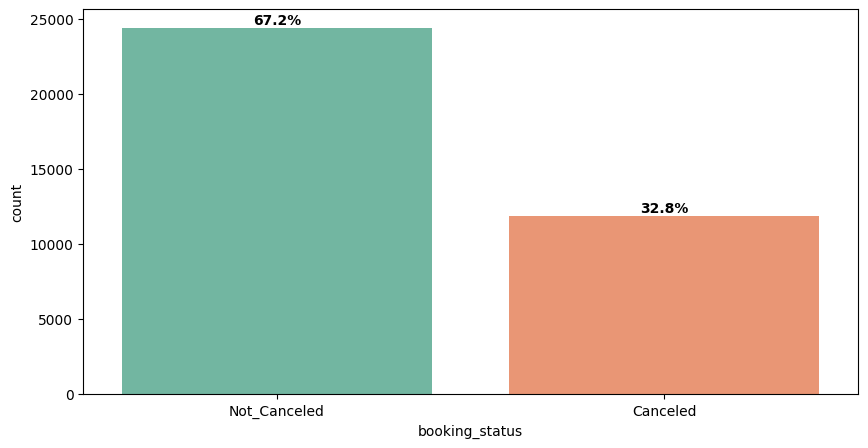

In [ ]:
labeled_barplot_analysis(df1, "booking_status")

- Majority Completed Stays: The majority of hotel bookings are successful, with 67.2% of reservations falling under the Not_Canceled category.
- Significant Cancellation Rate: A substantial portion of bookings, exactly 32.8%, end up being Canceled, indicating a high churn risk that requires optimization.
- Target Variable Insights: This distribution reveals a roughly $2:1$ ratio between successful and canceled bookings, serving as a well-balanced target column for machine learning classification models.

### Observations on type_of_meal_plan

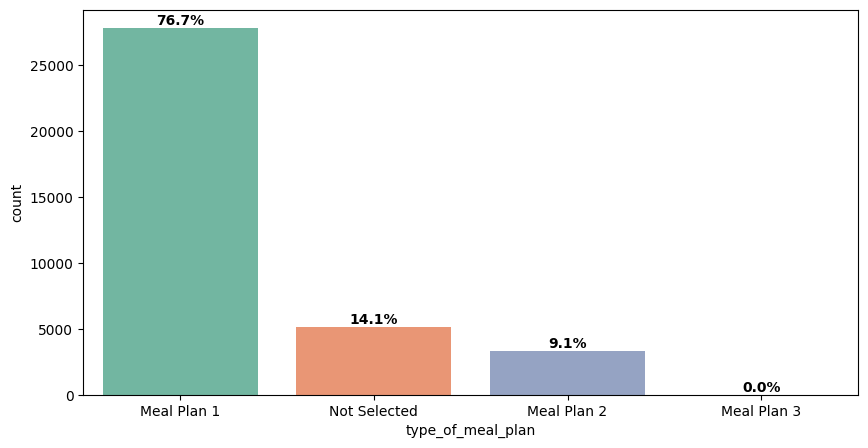

In [ ]:
labeled_barplot_analysis(df1, "type_of_meal_plan")

- Overwhelming Preference: Meal Plan 1 is the most popular choice by a huge margin, accounting for 76.7% of all bookings.

- No Meal Option: A smaller portion of guests, exactly 14.1%, opted out of food packages completely, falling under the Not Selected category.

- Minority Options: Meal Plan 2 captures only 9.1% of reservations, while Meal Plan 3 is practically negligible at 0.0%, indicating it might be worth removing or merging.

### Observations on room_type_reserved

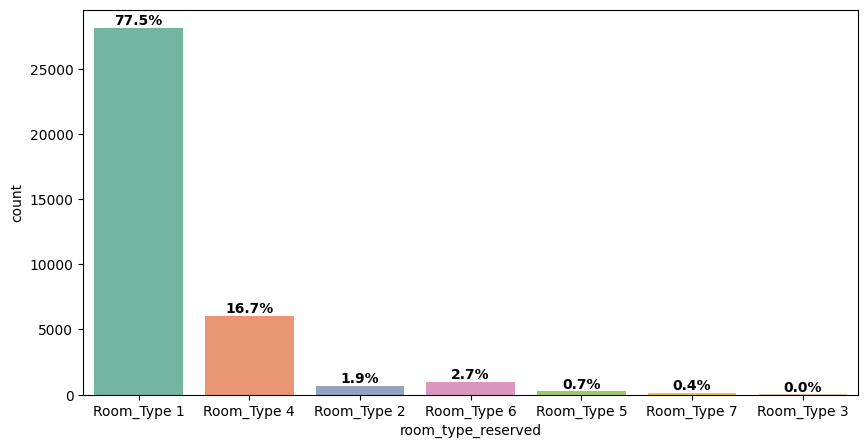

In [ ]:
labeled_barplot_analysis(df1, "room_type_reserved")

- Dominant Preference: Room_Type 1 is the most highly preferred accommodation, accounting for the overwhelming majority with 77.5% of total reservations.

- Secondary Choice: Room_Type 4 represents the second most popular category, capturing 16.7% of the bookings.

- Rare Selections: All other categories (Room_Type 2, 6, 5, 7, and 3) are extremely rare, contributing less than 6% combined to the entire dataset.

### Bivariate Analysis

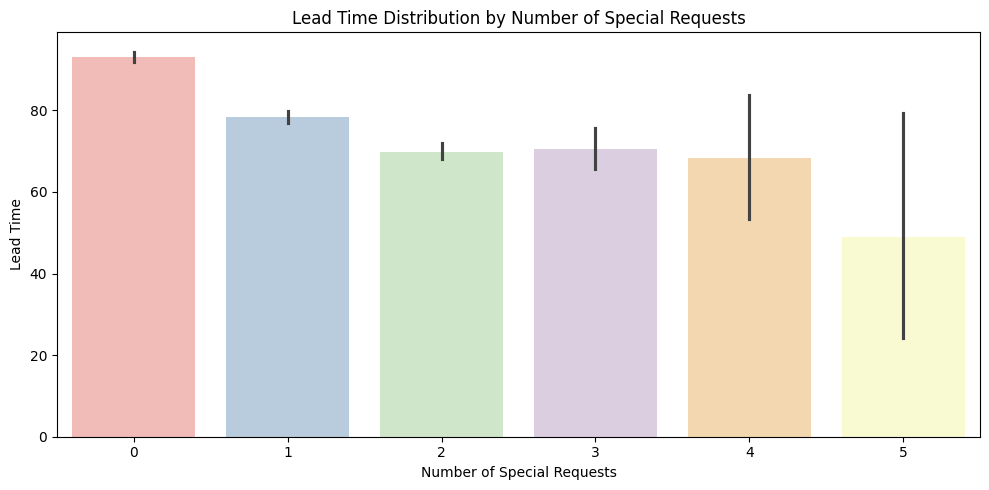

In [ ]:
plt.figure(figsize = (10,5))
sns.barplot(data = df1, x = "no_of_special_requests", y = "lead_time", palette = "Pastel1")
plt.title("Lead Time Distribution by Number of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Lead Time")
plt.tight_layout()
plt.show()

- Request Intensity vs Planning Window: Interestingly, bookings with zero special requests show a wider distribution and higher median lead time, suggesting that long-term planners tend to make fewer immediate demands.

- Short-Term Specific Demands: Guests who make multiple special requests (2 or 3+) tend to have a more compact, moderate lead time distribution. This indicates that their travel plans are highly specific, and their demands are immediate and well-thought-out closer to their stay.

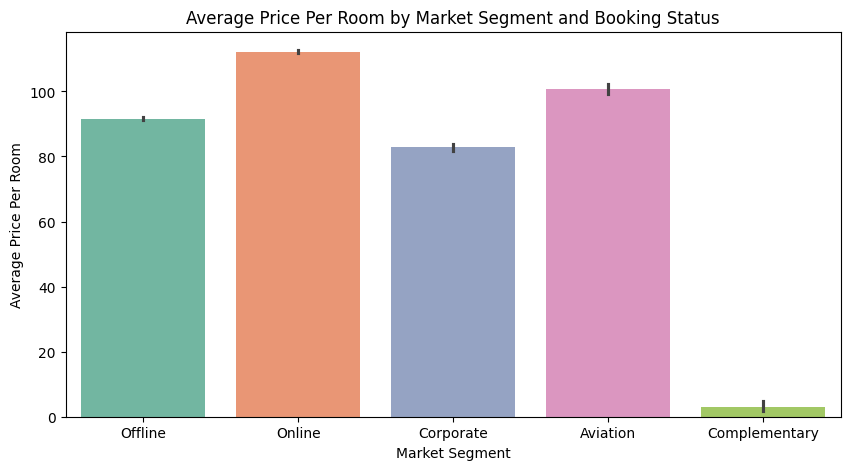

In [ ]:
plt.figure(figsize = (10,5))
sns.barplot(data = df1, x = "market_segment_type", y = "avg_price_per_room", palette = "Set2")
plt.title("Average Price Per Room by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Average Price Per Room")
plt.show()

- Premium Segments: The 'Online' and 'Aviation' segments yield the highest average price per room, acting as major revenue drivers for the hotel.

- Corporate Discounts: 'Corporate' and 'Complementary' segments display much lower average prices, reflecting corporate contract discounts and loyalty rewards.

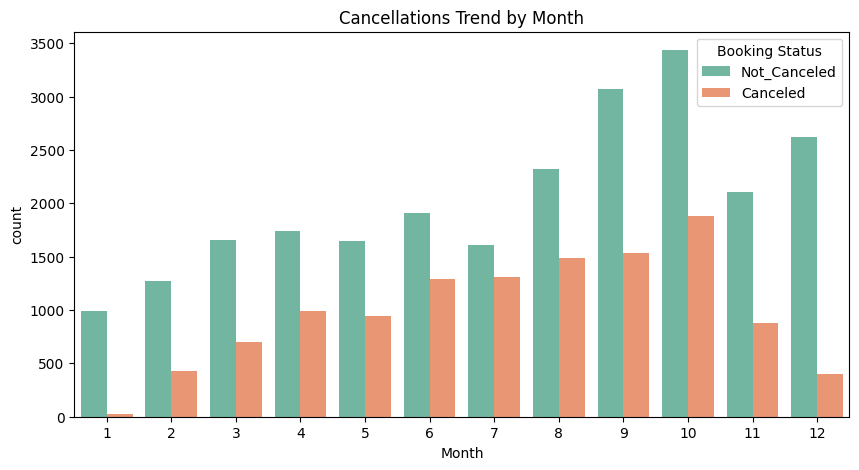

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(data = df1, x = "arrival_month", hue = "booking_status", palette = "Set2")
plt.title("Cancellations Trend by Month")
plt.xlabel("Month")
plt.legend(title = "Booking Status")
plt.show()

- Peak Season Spike: Peak travel months (like October and November) see the highest volume of bookings, which also results in a higher absolute count of cancellations.

- Off-Peak Consistency: Winter and off-season months show a low booking volume but maintain a very steady and stable cancellation-to-booking ratio.

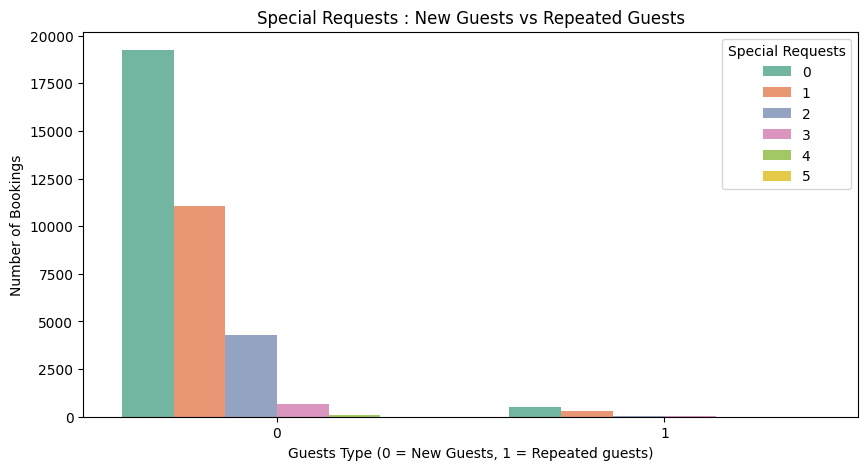

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(data = df1, x = "repeated_guest", hue = "no_of_special_requests", palette = "Set2")
plt.title("Special Requests : New Guests vs Repeated Guests")
plt.xlabel('Guests Type (0 = New Guests, 1 = Repeated guests)')
plt.ylabel("Number of Bookings")
plt.legend(title = "Special Requests")
plt.show()

- New Guest Behavior: The absolute volume of bookings comes from new guests (repeated_guest = 0), who mostly prefer standard arrangements with zero or minimal special requests.

- Loyalty and Expectations: Although 'Repeated Guests' (repeated_guest = 1) represent a smaller fraction of the dataset, they show a higher relative tendency to make special requests. Since they are familiar with the hotel’s services, they have specific expectations based on their past stays.

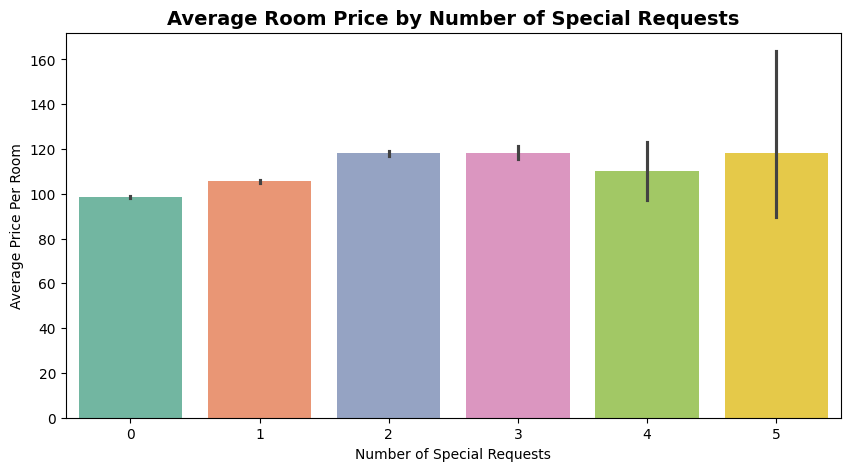

In [ ]:
plt.figure(figsize = (10,5))
sns.barplot(data = df1, x = "no_of_special_requests", y = "avg_price_per_room", palette = "Set2")
plt.title("Average Room Price by Number of Special Requests", fontsize = 14, fontweight = "bold")
plt.xlabel("Number of Special Requests")
plt.ylabel("Average Price Per Room")
plt.show()

- Premium Expectations: There is a clear upward trend showing that as the number of special requests increases from 0 to 3+, the average price per room also rises. This indicates that high-paying guests expect premium service and customized experiences during their stay.

- Low-Cost Simplicity: Guests paying lower average room prices rarely make more than one special request, which aligns with budget-conscious travelers who focus primarily on basic accommodation rather than extra amenities.

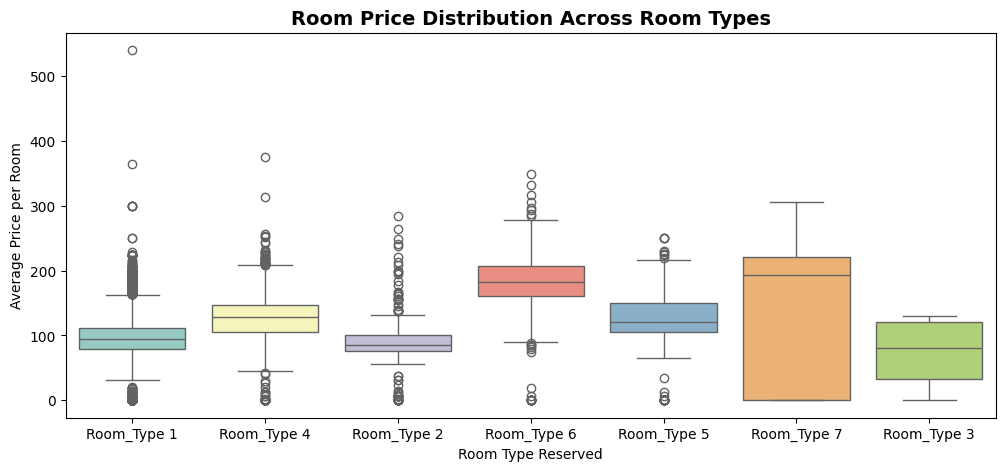

In [ ]:
plt.figure(figsize = (12,5))
sns.boxplot(data = df1, x = "room_type_reserved", y = "avg_price_per_room", palette = "Set3")
plt.title("Room Price Distribution Across Room Types", fontsize = 14, fontweight = "bold")
plt.xlabel("Room Type Reserved")
plt.ylabel("Average Price per Room")
plt.show()

- Room Pricing Hierarchy: The box plot illustrates a distinct pricing hierarchy across different room types. Certain premium room categories command significantly higher average prices, representing the hotel’s luxury suites or family rooms.

- Standard Room Consistency: The most common room types show a very tight price range with fewer extreme variations, indicating a standardized and fixed pricing strategy for the hotel's core inventory.

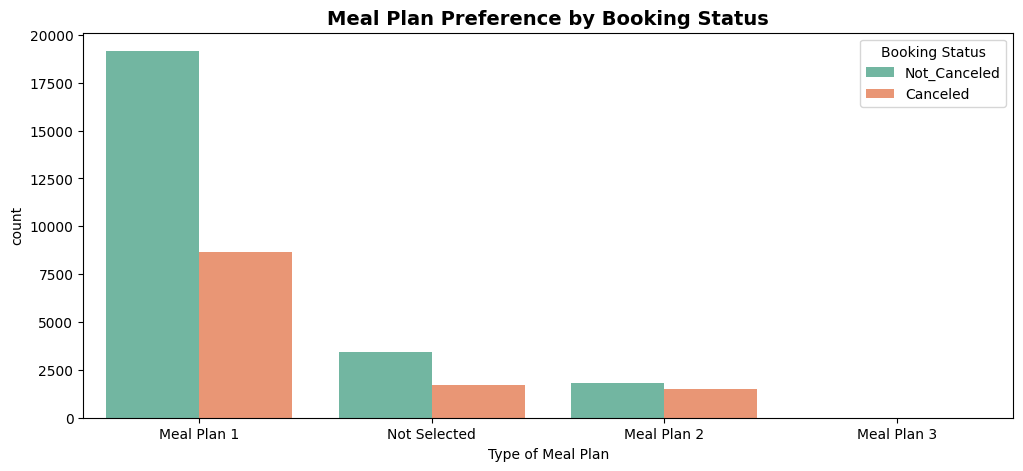

In [ ]:
plt.figure(figsize = (12,5))
sns.countplot(data = df1, x = "type_of_meal_plan", hue = "booking_status", palette = "Set2")
plt.title("Meal Plan Preference by Booking Status", fontsize = 14, fontweight = "bold")
plt.xlabel("Type of Meal Plan")
plt.legend(title = "Booking Status")
plt.show()

- Meal Plan Preferences: The vast majority of guests opt for 'Meal Plan 1' (typically breakfast included), which also sees the highest absolute number of cancellations due to its sheer volume.

- All-Inclusive Commitment: Guests who book all-inclusive meal plans (like 'Meal Plan 2' or full board) tend to have a lower cancellation percentage. This demonstrates that customers who commit to dining at the hotel have a stronger, more definite travel intent.

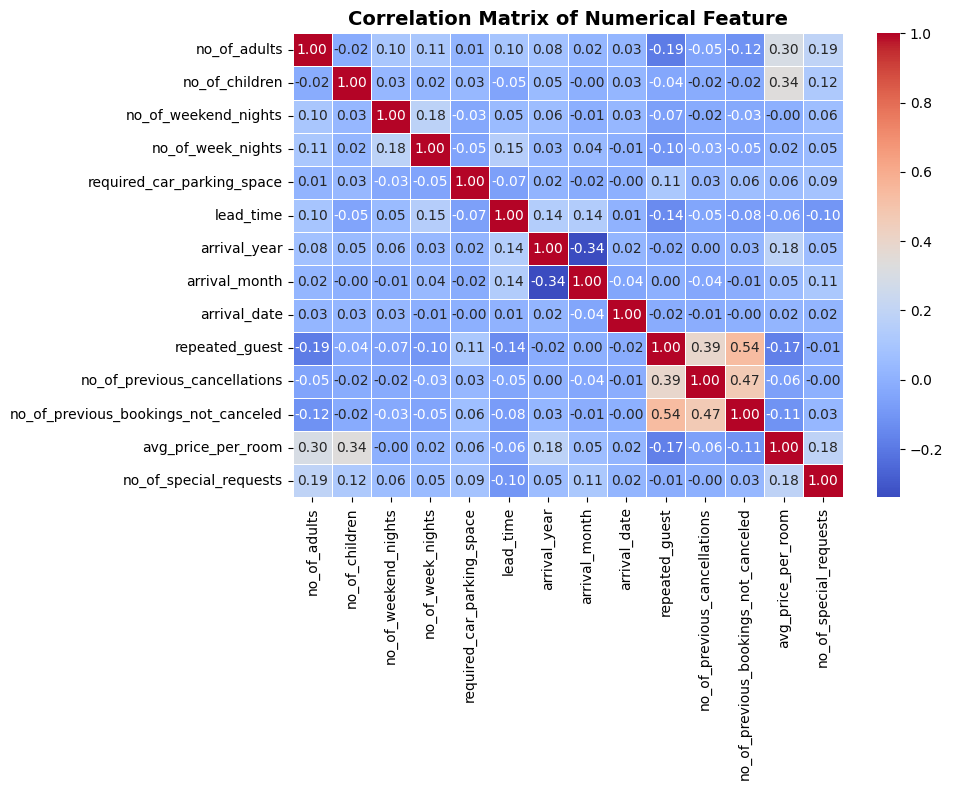

In [ ]:
plt.figure(figsize = (10,8))

numerical_columns = df1.select_dtypes(include = ['int64','float64'])
corr_mtx = numerical_columns.corr()
sns.heatmap(corr_mtx, annot = True, cmap = "coolwarm", fmt = ".2f", linewidth = 0.5)
plt.title("Correlation Matrix of Numerical Feature", fontsize = 14, fontweight = "bold")
plt.tight_layout()
plt.show()

<Figure size 1500x1500 with 0 Axes>

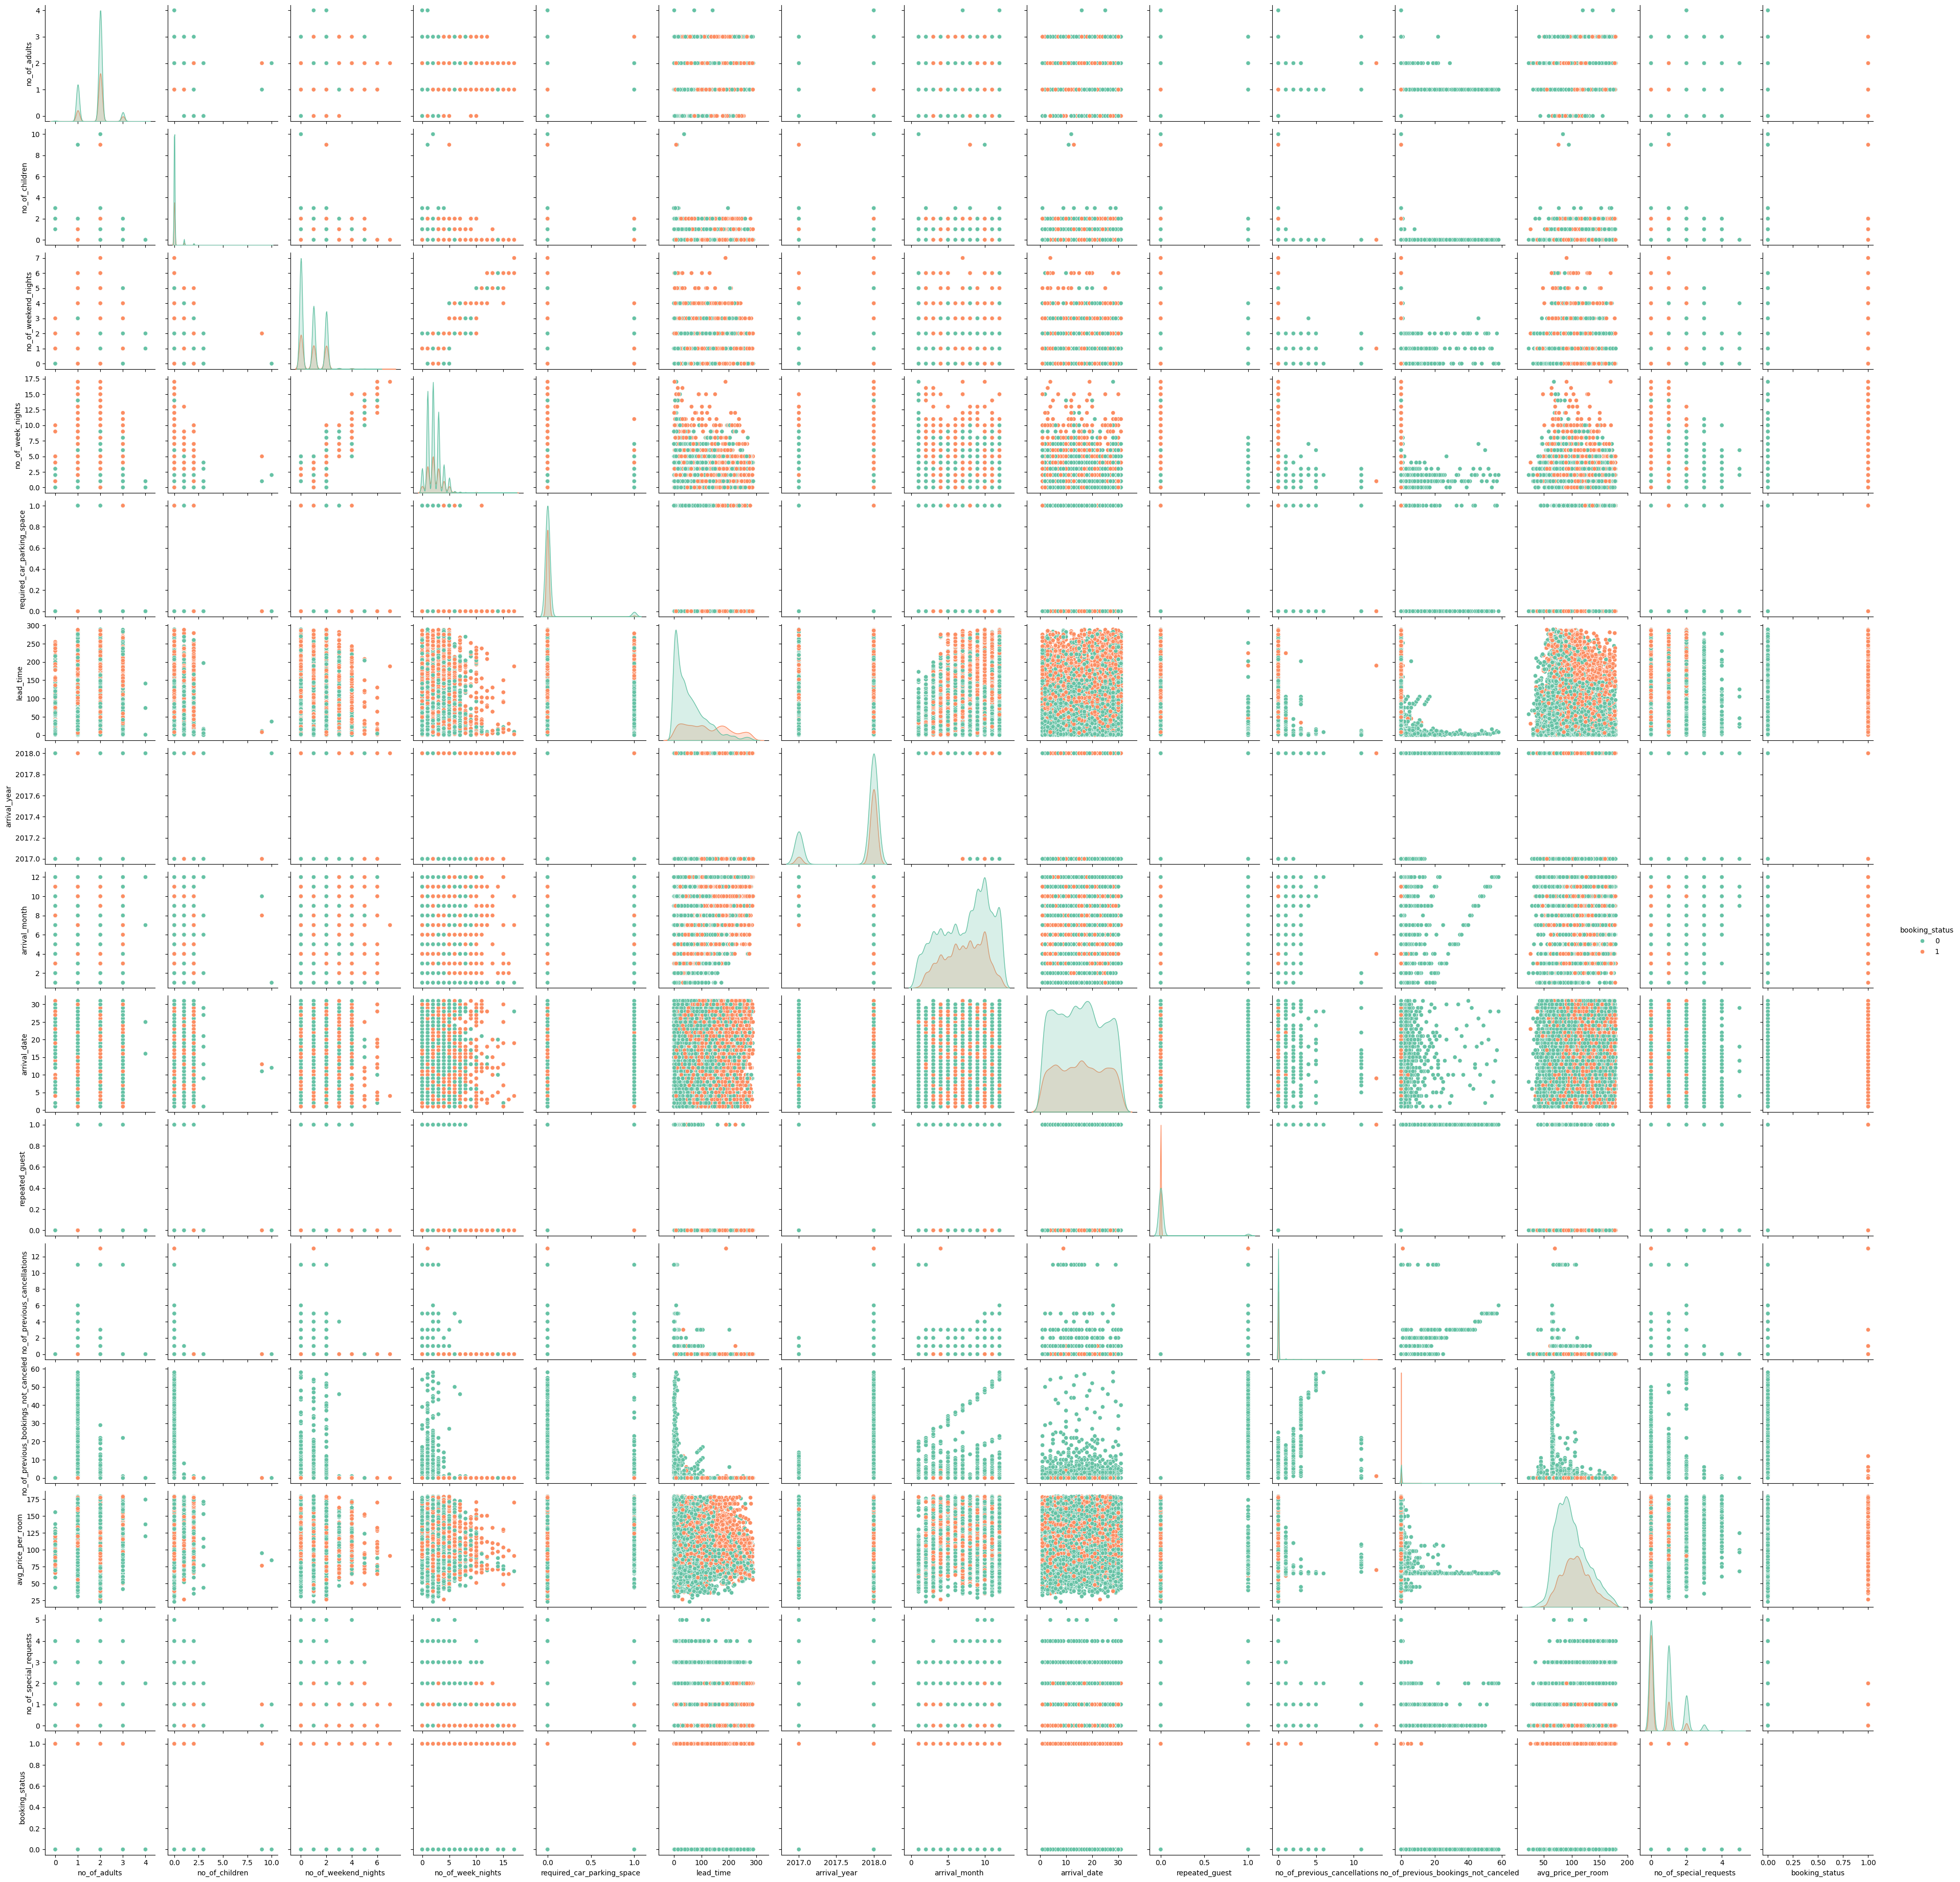

In [ ]:
numerical_cols = df1.select_dtypes(include = ['int64','float64'])

plt.figure(figsize = (15,15))
sns.pairplot(df1, vars=numerical_cols, hue = "booking_status", palette = "Set2")
plt.show()

### Outliers Handling using IQR Method

#### Outliers remove in lead time column

In [ ]:
Q1 = df1['lead_time'].quantile(0.25)
Q3 = df1['lead_time'].quantile(0.75)

print("Quartile25 = ",Q1)
print("Quartile75 = ",Q3)

IQR = Q3 - Q1
print("Inter Quartile Range = ",IQR)

Quartile25 =  17.0
Quartile75 =  126.0
Inter Quartile Range =  109.0


In [ ]:
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR
print("Upper Limit = ",upper_limit)
print("Lower Limit = ",lower_limit)

Upper Limit =  289.5
Lower Limit =  -146.5


In [ ]:
df1 = df1[(df1["lead_time"] >= lower_limit) & (df1["lead_time"] <= upper_limit)]

#### outliers remove in avg_price_per_room

In [ ]:
Q1_price = df['avg_price_per_room'].quantile(0.25)
Q3_price = df['avg_price_per_room'].quantile(0.75)

print("Quartile25 = ",Q1_price)
print("Quartile75 = ",Q3_price)

IQR_price = Q3_price - Q1_price
print("Inter Quartile Range = ",IQR_price)

Quartile25 =  80.3
Quartile75 =  120.0
Inter Quartile Range =  39.7


In [ ]:
lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

print("Upper Limit = ",upper_price)
print("Lower Limit = ",lower_price)

Upper Limit =  179.55
Lower Limit =  20.749999999999993


In [ ]:
df1 = df1[(df1['avg_price_per_room'] >= lower_price) & (df1['avg_price_per_room'] <= upper_price)]

In [ ]:
print("After Check Outliers Removed : ", df1.shape)

After Check Outliers Removed :  (33259, 18)


### Feature Encoding

In [ ]:
df1['booking_status'] = df1['booking_status'].map({'Canceled' : 1, 'Not_Canceled' : 0})

In [ ]:
df_encoded = pd.get_dummies(df1, drop_first = True)
print("After use Encoding : ", df_encoded.shape)

After use Encoding :  (33259, 27)


### X and Y Separating

In [ ]:
X = df_encoded.drop(columns = ["booking_status"])
Y = df_encoded["booking_status"]

print("Shape of X : ", X.shape)
print("Shape of Y : ", Y.shape)

Shape of X :  (33259, 26)
Shape of Y :  (33259,)


### Train Test Split (80% Train, 20% Test)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

print("Shape of X_train : ", X_train.shape)
print("Shape of X_test : ", X_test.shape)

Shape of X_train :  (26607, 26)
Shape of X_test :  (6652, 26)


### Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Biuld

#### K Nearest Neighbor Model

In [ ]:
KNN = KNeighborsClassifier()
KNN.fit(X_train_scaled, Y_train)

KNeighborsClassifier()

In [ ]:
KNN_pred = KNN.predict(X_test_scaled)
KNN_acc = accuracy_score(Y_test, KNN_pred)

print(f"KNN Accuracy = {KNN_acc * 100:.2f}")
print("\n Detailed Classification Report : \n")
print(classification_report(Y_test, KNN_pred))

KNN Accuracy = 84.55

 Detailed Classification Report : 

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      4610
           1       0.76      0.73      0.74      2042

    accuracy                           0.85      6652
   macro avg       0.82      0.81      0.82      6652
weighted avg       0.84      0.85      0.84      6652



#### Logistic Regression Model

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, Y_train)

LogisticRegression()

In [ ]:
lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(Y_test, lr_pred)

print(f"Logistic Regression Accuracy = {lr_acc * 100:.2f}")
print("\n Detailed Classification Report : \n")
print(classification_report(Y_test, lr_pred))

Logistic Regression Accuracy = 81.36

 Detailed Classification Report : 

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      4610
           1       0.74      0.61      0.67      2042

    accuracy                           0.81      6652
   macro avg       0.79      0.76      0.77      6652
weighted avg       0.81      0.81      0.81      6652



#### Support Vector Classifeir Model

In [ ]:
svm = SVC()
svm.fit(X_train_scaled, Y_train)

SVC()

In [ ]:
svm_pred = svm.predict(X_test_scaled)
svm_acc = accuracy_score(Y_test, svm_pred)

print(f"SVM Accuracy = {svm_acc * 100:.2f}")
print("\n Detailed Classification Report : \n")
print(classification_report(Y_test, svm_pred))

SVM Accuracy = 84.25

 Detailed Classification Report : 

              precision    recall  f1-score   support

           0       0.86      0.92      0.89      4610
           1       0.79      0.66      0.72      2042

    accuracy                           0.84      6652
   macro avg       0.83      0.79      0.80      6652
weighted avg       0.84      0.84      0.84      6652



#### Naive Bayes Model

In [ ]:
nb = GaussianNB()
nb.fit(X_train_scaled, Y_train)

GaussianNB()

In [ ]:
nb_pred = nb.predict(X_test_scaled)
nb_acc = accuracy_score(Y_test, nb_pred)

print(f"Naive Bayes Accuracy = {nb_acc * 100:.2f}")
print("\n Detailed Classification Report : \n")
print(classification_report(Y_test, nb_pred))

Naive Bayes Accuracy = 38.44

 Detailed Classification Report : 

              precision    recall  f1-score   support

           0       0.93      0.12      0.21      4610
           1       0.33      0.98      0.49      2042

    accuracy                           0.38      6652
   macro avg       0.63      0.55      0.35      6652
weighted avg       0.74      0.38      0.30      6652



##### Confusion Matrix

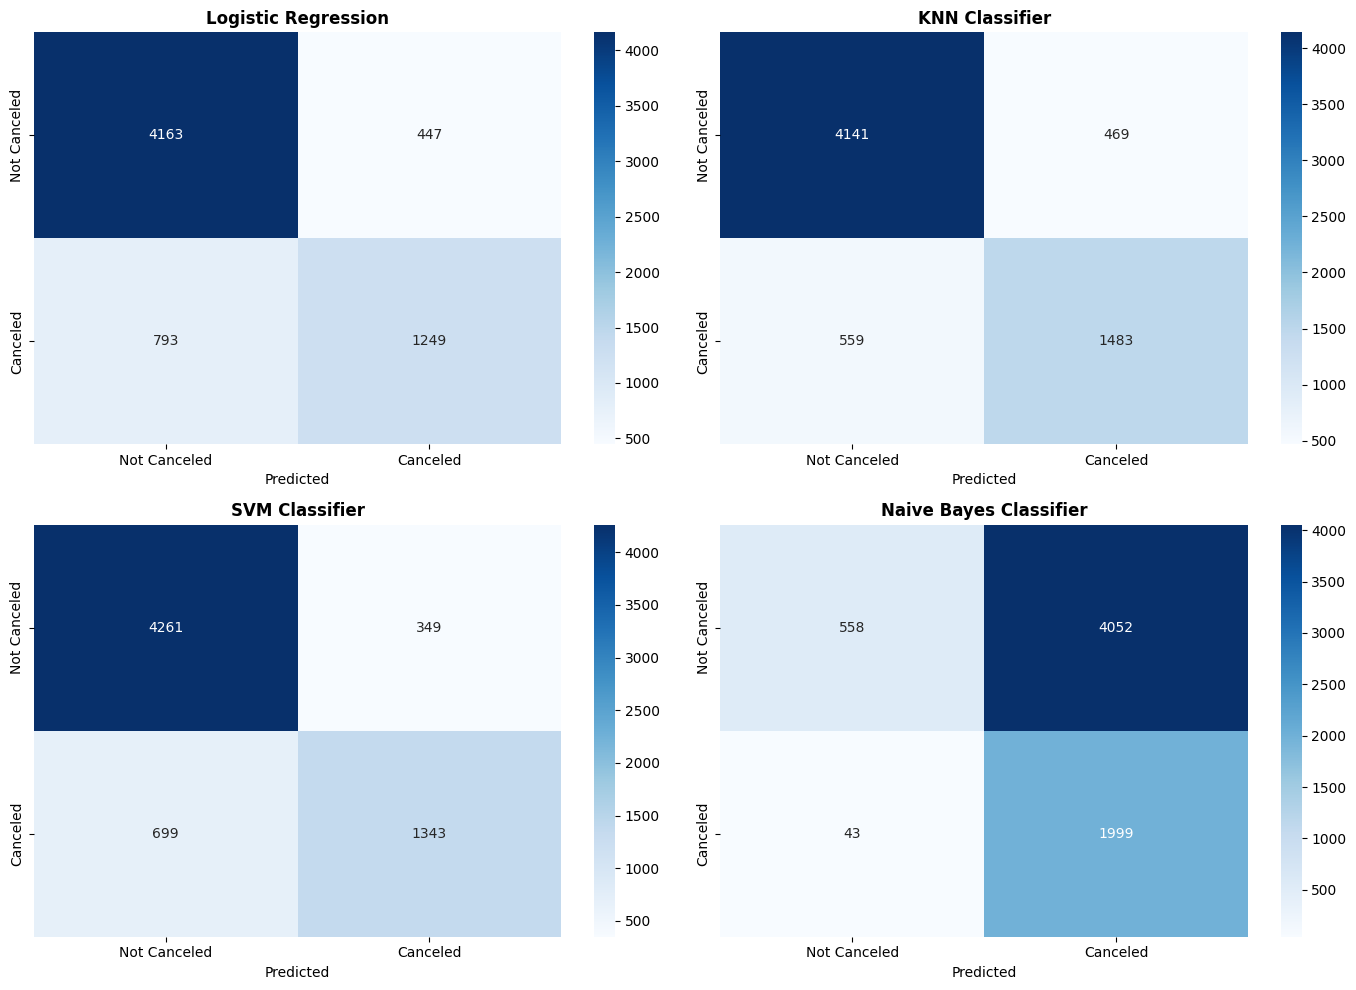

In [ ]:
all_preds = [lr_pred, KNN_pred, svm_pred, nb_pred]
model_names = ['Logistic Regression', 'KNN Classifier', 'SVM Classifier','Naive Bayes Classifier']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (pred, name) in enumerate(zip(all_preds, model_names)):
    cm = confusion_matrix(Y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Canceled', 'Canceled'],
                yticklabels=['Not Canceled', 'Canceled'])
    axes[i].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## Conclusion Observation

### Key Project Observations & Cancellation Analysis

After analyzing the final dataset and evaluating the classification metrics of all 4 models, the following major observations were established:

* **The Lead Time Impact:** Bookings made with high lead times (guests booking months in advance) are highly unstable and carry the maximum risk of cancellation compared to last-minute bookings.
* **Online Channel Volatility:** A huge chunk of reservations (64%) comes from online channels. Because online platforms offer flexible cancellation policies with no advance deposits, guests cancel easily without any financial risk.
* **Customer Engagement Factor:** There is a clear pattern showing that guests who make special requests (like room preferences or extra beds) rarely cancel their bookings, whereas guests with zero special requests show low commitment and cancel frequently.
* **The Cancellation Root-Cause (Business Impact):**
  * Customers cancel primarily due to **Price Sensitivity** (higher room rates lead to dropping out if a cheaper deal is found) and **Lack of Financial Penalty** (no upfront deposit required).
  * High cancellation rates cause severe **Revenue Leakage** and complicate inventory management, as the hotel cannot predict actual room occupancy until the last minute.
* **Model Efficiency & Comparison:**
  * **KNN (84.55%)** and **SVM (84.25%)** are the most accurate models, proving they are highly capable of capturing complex customer behaviors.
  * **Logistic Regression (81.36%)** performs decently as a linear baseline but misses non-linear patterns.
  * **Naive Bayes (38.44%)** failed completely because it over-predicts cancellations, giving a high False Positive rate that makes it useless for hotel operations.
* **The Loyalty Gap:** Repeated guests represent an extremely small, negligible fraction of the total dataset, indicating that the hotel relies heavily on one-time customers and lacks a system to bring guests back.
* **Final Cancellation Verdict:** To minimize losses from cancellations, the hotel must shift from a flexible/free model to a **Risk-Based Predictive Model**—implementing strict advance non-refundable deposits on high lead-time online bookings flagged by our KNN model.